# ResNet-18 (Augmented + LR Scheduler)

## Changes from Unfreeze Baseline

### What changed
| | Unfreeze | Augmented |
|---|---|---|
| Augmentation | HFlip + ±10° rotation | HFlip + VFlip + ±30° rotation + ColorJitter + RandomAffine |
| Optimizer | Adam | AdamW |
| Weight decay | None | 1e-4 (decoupled) |
| LR scheduler | None | CosineAnnealingLR |
| Dropout | None | 0.4 before FC |
| Inference | Single pass | TTA (8 augmented passes averaged) |

### Rationale
The unfreeze model overfits heavily — train F2 reaches 0.97 while val F2 peaks at 0.78. Three changes target this:

1. **Stronger augmentation**: More transforms (vertical flip, wider rotation, color jitter, affine shifts) force the model to learn general melanoma features rather than memorizing specific training images.

2. **AdamW + weight decay**: AdamW decouples weight decay from the gradient update, fixing a known issue with standard Adam where weight decay interacts incorrectly with adaptive learning rates. This is the correct way to apply L2 regularization with Adam-style optimizers.

3. **Dropout (0.4)**: Applied before the FC layer, dropout randomly disables 40% of neurons during training, preventing any single pathway from dominating and forcing more robust feature learning.

4. **Test-Time Augmentation (TTA)**: At inference, each image is passed through 8 different augmentations (flips, rotations). The sigmoid probabilities are averaged before thresholding, giving a more stable and accurate prediction without any retraining.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False, dropout=0.4).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

Positive weight: tensor([6.0244], device='mps:0')


In [ ]:
best_val_f2 = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/resnet_augmented_v2_best.pth')
        print('Saved best model at epoch', epoch+1)

## Plot Loss and Accuracy Curves

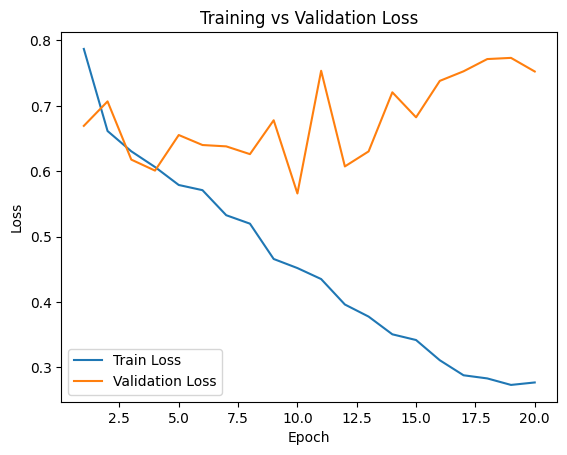

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

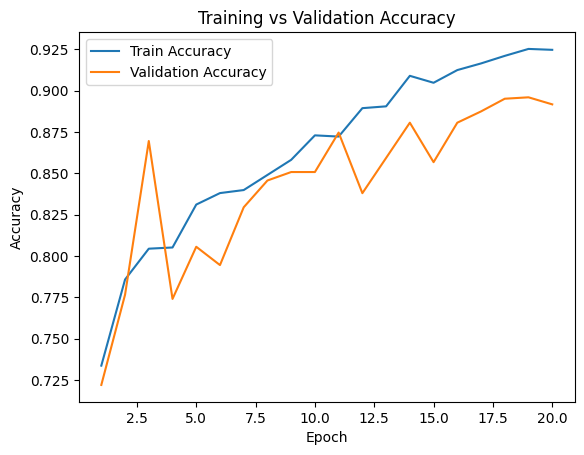

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

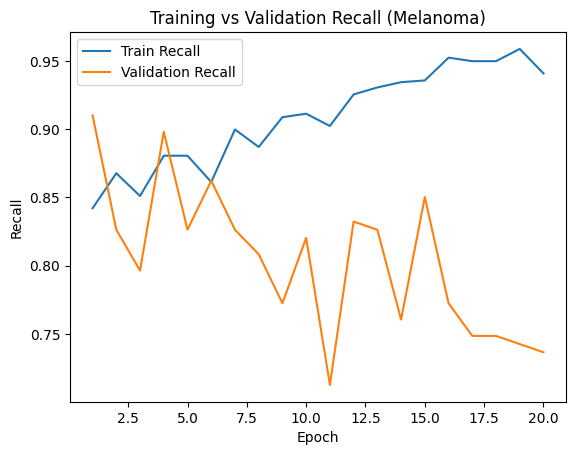

In [7]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

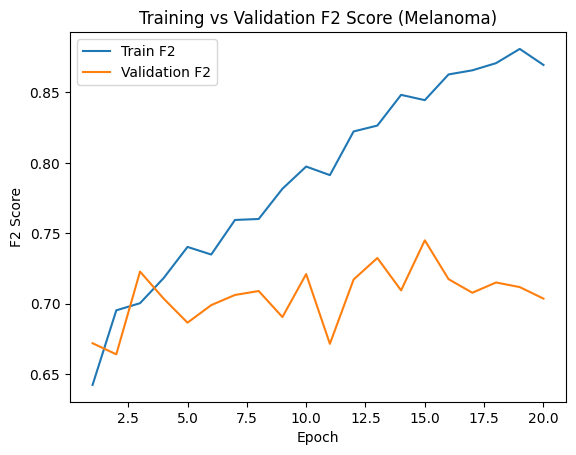

In [8]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [ ]:
import numpy as np
from sklearn.metrics import fbeta_score
from torchvision import transforms

model.load_state_dict(torch.load('../models/resnet_augmented_v2_best.pth', map_location=device))
model.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tta_transforms = [
    transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(90, 90)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(180, 180)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(270, 270)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.ColorJitter(brightness=0.1, contrast=0.1), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

def tta_predict(model, dataset, device, tta_transforms):
    all_probs = []
    all_labels = []

    for idx in range(len(dataset)):
        image_path = dataset.image_dir / dataset.data.iloc[idx]['image_id']
        label = 1 - int(dataset.data.iloc[idx]['label'])
        from PIL import Image
        img = Image.open(image_path).convert('RGB')

        preds = []
        with torch.no_grad():
            for t in tta_transforms:
                tensor = t(img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor)).item()
                preds.append(prob)

        all_probs.append(np.mean(preds))
        all_labels.append(label)

    return np.array(all_probs), np.array(all_labels)

val_probs, val_labels = tta_predict(model, val_loader.dataset, device, tta_transforms)

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

test_probs, test_labels = tta_predict(model, test_loader.dataset, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

In [11]:
cm = confusion_matrix(test_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[899 107]
 [ 28 139]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [12]:
print(classification_report(test_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9698    0.8936    0.9302      1006
           1     0.5650    0.8323    0.6731       167

    accuracy                         0.8849      1173
   macro avg     0.7674    0.8630    0.8016      1173
weighted avg     0.9122    0.8849    0.8936      1173



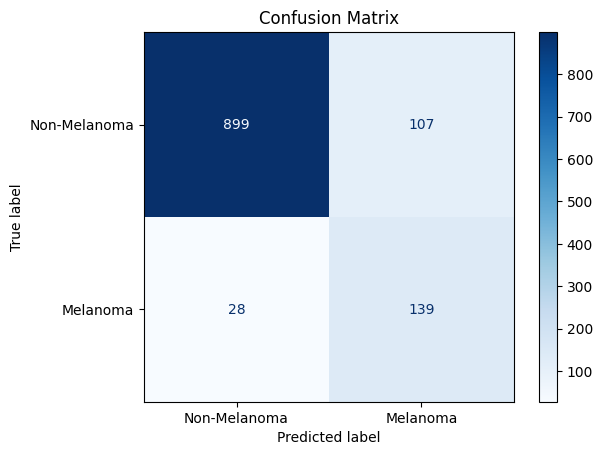

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()